# HiGAN+ Handwriting Generation Model

This notebook implements the HiGAN+ (Hierarchical Generative Adversarial Network) model for handwriting generation from scratch. The model includes:
- **Generator**: Generates handwritten text images from style vectors and text content
- **Discriminator**: Global and patch-based discriminators for realistic image generation
- **Style Encoder**: Extracts style information from reference handwriting
- **OCR Network**: Ensures generated text is readable
- **Writer Identifier**: Preserves writer-specific characteristics

## Architecture Overview
- **Training Phase**: Train the GAN model with multiple loss functions
- **Evaluation Phase**: Calculate FID, KID, IS, CER, WER metrics
- **Inference Phase**: Generate new handwriting samples

## 1. Import Libraries and Setup

In [1]:
import sys
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import h5py
import cv2
from datetime import datetime

## Jugad pro
# Fix for Pillow>=10 where Image.ANTIALIAS moved under Image.Resampling
if not hasattr(Image, "ANTIALIAS"):
    Image.ANTIALIAS = Image.Resampling.LANCZOS

project_path = r"/home/studentiotlab/ML_Model/Higan+ from Scratch"

os.chdir(project_path)  # change dir
if str(project_path) not in sys.path:
    sys.path.insert(0, str(project_path))

print(f"Project path: {project_path}")

Project path: /home/studentiotlab/ML_Model/Higan+ from Scratch


In [2]:
# higan modules
from lib.datasets import get_dataset, get_collect_fn, Hdf5Dataset
from lib.alphabet import strLabelConverter, Alphabets
from lib.utils import yaml2config, draw_image, AverageMeter
from networks import get_model
from networks.BigGAN_networks import Generator, Discriminator, PatchDiscriminator
from networks.module import Recognizer, WriterIdentifier, StyleEncoder, StyleBackbone
from torch.utils.data import DataLoader

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

PyTorch version: 2.9.0+cu130
CUDA available: True
CUDA device: NVIDIA L40S

Using device: cuda


## 2. Load Configuration and Dataset

In [3]:
config_path = os.path.join(project_path, 'configs', 'gan_iam.yml')
cfg = yaml2config(config_path)

cfg.device = str(device)
cfg.training.batch_size = 24
cfg.training.epochs = 70  # Fewer epochs for demo
cfg.training.print_iter_val = 500
cfg.training.sample_iter_val = 400

print("Configuration done :D")
print(f"Dataset: {cfg.dataset}")
print(f"Model: {cfg.model}")
print(f"Batch size: {cfg.training.batch_size}")
print(f"Epochs: {cfg.training.epochs}")
print(f"Image height: {cfg.img_height}")
print(f"Character width: {cfg.char_width}")

Configuration done :D
Dataset: iam_word_org
Model: gl_adversarial_model
Batch size: 24
Epochs: 70
Image height: 64
Character width: 32


In [4]:
# Create dataset with the necessary augmentations and dataloader object from hdf5
print("\nLoading dataset...")

collect_fn = get_collect_fn(cfg.training.sort_input, sort_style=True)
try:
    train_dataset = get_dataset(
        cfg.dataset, 
        cfg.training.dset_split,
        recogn_aug=True, 
        wid_aug=True, 
        process_style=True
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.training.batch_size,
        shuffle=True,
        collate_fn=collect_fn,
        num_workers=0,  # Set to 0 for notebook
        drop_last=True
    )
    
    test_dataset = get_dataset(
        cfg.valid.dset_name,
        cfg.valid.dset_split,
        recogn_aug=False,
        wid_aug=False,
        process_style=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=cfg.training.eval_batch_size // 2,
        shuffle=True,
        collate_fn=collect_fn,
        num_workers=0
    )
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    print(f"Training batches: {len(train_loader)}")
    
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("\nNote: Make sure the IAM dataset HDF5 files are in the correct location:")
    print("  - b:\\College\\DL\\Higan+ from Scratch\\iam\\trnvalset_words64_OrgSz.hdf5")
    print("  - b:\\College\\DL\\Higan+ from Scratch\\iam\\testset_words64_OrgSz.hdf5")


Loading dataset...
Training samples: 52231
Test samples: 11170
Training batches: 2176


## 3. Visualize Sample Data

In [5]:
import PIL
print(PIL.__version__)

12.0.0


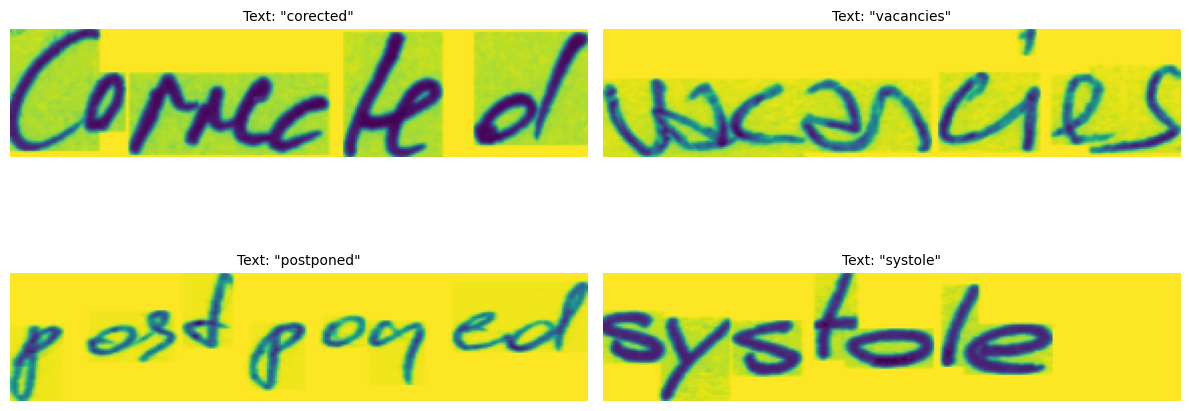


Batch shape: torch.Size([24, 1, 64, 288])
Label shape: torch.Size([24, 9])
Sample texts: ['corected', 'vacancies', 'postponed', 'systole']


In [6]:
# Visualize some training samples
try:
    sample_batch = next(iter(train_loader))
    
    label_converter = strLabelConverter('all')
    
    # Get images and labels
    imgs = sample_batch['style_imgs'] # word image
    lbs = sample_batch['lbs'] # label in numerical format
    lb_lens = sample_batch['lb_lens'] # length in chars
    
    # Decode labels
    texts = label_converter.decode(lbs, lb_lens)
    
    # Plot samples
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    axes = axes.ravel()
    
    for i in range(min(4, imgs.size(0))):
        img = imgs[i].squeeze().numpy()
        # Convert from [-1, 1] to [0, 1] for display
        img = (1 - img) / 2
        axes[i].imshow(img, cmap='viridis')
        axes[i].set_title(f'Text: "{texts[i]}"', fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nBatch shape: {imgs.shape}")
    print(f"Label shape: {lbs.shape}")
    print(f"Sample texts: {texts[:4]}")

except Exception as e:
    print(f"Could not visualize samples: {e}")

Dataset summary (word lengths):
  Train -> samples: 52231, min: 2, max: 19, mean: 4.76, median: 4.00
  Test -> samples: 11170, min: 2, max: 21, mean: 4.44, median: 4.00
Unique writer IDs in training set: 372


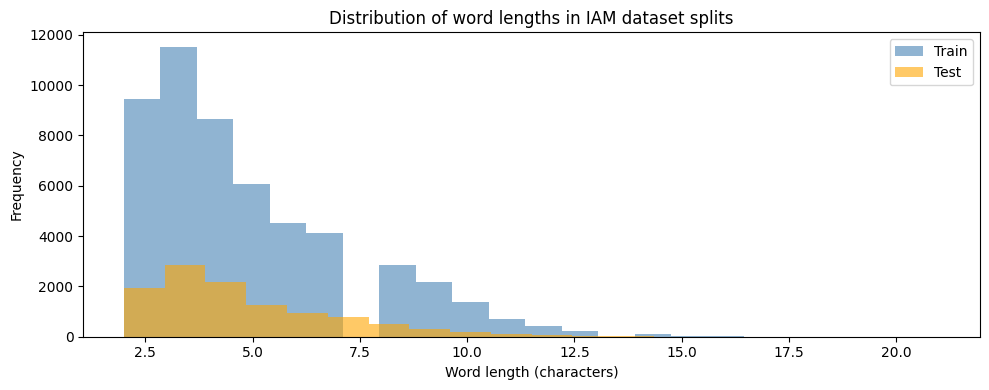

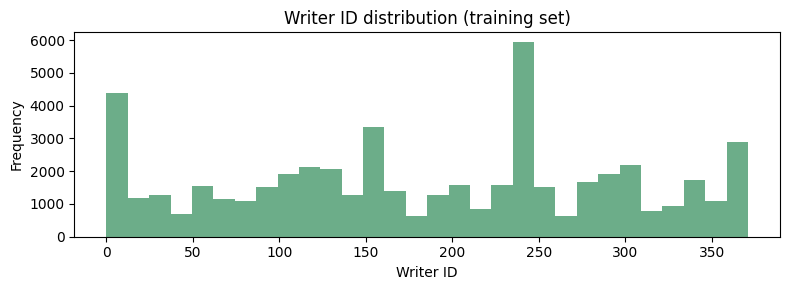

In [7]:
# Dataset statistics overview
import numpy as np

train_word_lengths = np.asarray(train_dataset.lb_lens)
train_writer_ids = np.asarray(train_dataset.wids)
test_lengths_raw = np.asarray(test_dataset.lb_lens)
test_word_lengths = test_lengths_raw

def summarize_lengths(lengths, label):
    lengths = np.asarray(lengths)
    if lengths.size == 0:
        return {
            'label': label,
            'count': 0,
            'mean': 0.0,
            'median': 0.0,
            'min': 0,
            'max': 0
        }
    return {
        'label': label,
        'count': lengths.size,
        'mean': float(np.mean(lengths)),
        'median': float(np.median(lengths)),
        'min': int(np.min(lengths)),
        'max': int(np.max(lengths))
    }

train_summary = summarize_lengths(train_word_lengths, 'Train')
test_summary = summarize_lengths(test_word_lengths, 'Test')

print("Dataset summary (word lengths):")
for summary in [train_summary, test_summary]:
    print(f"  {summary['label']} -> samples: {summary['count']}, min: {summary['min']}, "
            f"max: {summary['max']}, mean: {summary['mean']:.2f}, median: {summary['median']:.2f}")

unique_writers = np.unique(train_writer_ids) if train_writer_ids.size else []
print(f"Unique writer IDs in training set: {len(unique_writers)}")

if train_word_lengths.size:
    plt.figure(figsize=(10, 4))
    plt.hist(train_word_lengths, bins=20, alpha=0.6, label='Train', color='steelblue')
    if np.asarray(test_word_lengths).size:
        plt.hist(test_word_lengths, bins=20, alpha=0.6, label='Test', color='orange')
    plt.xlabel('Word length (characters)')
    plt.ylabel('Frequency')
    plt.title('Distribution of word lengths in IAM dataset splits')
    plt.legend()
    plt.tight_layout()
    plt.show()

if train_writer_ids.size:
    plt.figure(figsize=(8, 3))
    plt.hist(train_writer_ids, bins=30, color='seagreen', alpha=0.7)
    plt.xlabel('Writer ID')
    plt.ylabel('Frequency')
    plt.title('Writer ID distribution (training set)')
    plt.tight_layout()
    plt.show()

## 4. Initialize HiGAN+ Model

In [8]:
print("Initializing HiGAN+ model components...")

# Initialize Generator
generator = Generator(**cfg.GenModel).to(device)
print(f"✓ Generator initialized - Style dim: {generator.style_dim}")

# Initialize Discriminators
discriminator = Discriminator(**cfg.DiscModel).to(device)
patch_discriminator = PatchDiscriminator(**cfg.PatchDiscModel).to(device)
print(f"✓ Discriminators initialized (Global + Patch)")

# Initialize Style Encoder & Backbone
style_backbone = StyleBackbone(**cfg.StyBackbone).to(device)
style_encoder = StyleEncoder(**cfg.EncModel).to(device)
print(f"✓ Style Encoder initialized")

# Initialize Recognizer (OCR)
recognizer = Recognizer(**cfg.OcrModel).to(device)
print(f"✓ OCR Recognizer initialized")

# Initialize Writer Identifier
writer_identifier = WriterIdentifier(**cfg.WidModel).to(device)
print(f"✓ Writer Identifier initialized")

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Model Parameters ---")
print(f"Generator: {count_parameters(generator):,}")
print(f"Discriminator: {count_parameters(discriminator):,}")
print(f"Patch Discriminator: {count_parameters(patch_discriminator):,}")
print(f"Style Encoder: {count_parameters(style_encoder):,}")
print(f"Style Backbone: {count_parameters(style_backbone):,}")
print(f"Recognizer: {count_parameters(recognizer):,}")
print(f"Writer ID: {count_parameters(writer_identifier):,}")
print(f"\nTotal Parameters: {count_parameters(generator) + count_parameters(discriminator) + count_parameters(patch_discriminator) + count_parameters(style_encoder) + count_parameters(style_backbone) + count_parameters(recognizer) + count_parameters(writer_identifier):,}")

Initializing HiGAN+ model components...
✓ Generator initialized - Style dim: 32
✓ Discriminators initialized (Global + Patch)
✓ Style Encoder initialized
✓ OCR Recognizer initialized
✓ Writer Identifier initialized

--- Model Parameters ---
Generator: 3,935,937
Discriminator: 2,366,145
Patch Discriminator: 2,366,145
Style Encoder: 148,032
Style Backbone: 1,617,328
Recognizer: 2,428,416
Writer ID: 161,396

Total Parameters: 13,023,399


In [9]:
# Load pretrained OCR and Writer ID models (if available)
print("\nLoading pretrained auxiliary models...")

try:
    # Load pretrained OCR
    if os.path.exists(cfg.training.pretrained_r):
        r_dict = torch.load(cfg.training.pretrained_r, map_location=device)
        recognizer.load_state_dict(r_dict['Recognizer'])
        print(f"✓ Loaded pretrained OCR from {cfg.training.pretrained_r}")
    else:
        print(f"⚠ Pretrained OCR not found: {cfg.training.pretrained_r}")
    
    # Load pretrained Writer ID
    if os.path.exists(cfg.training.pretrained_w):
        w_dict = torch.load(cfg.training.pretrained_w, map_location=device)
        writer_identifier.load_state_dict(w_dict['WriterIdentifier'])
        style_backbone.load_state_dict(w_dict['StyleBackbone'])
        print(f"✓ Loaded pretrained Writer ID from {cfg.training.pretrained_w}")
    else:
        print(f"⚠ Pretrained Writer ID not found: {cfg.training.pretrained_w}")

except Exception as e:
    print(f"⚠ Error loading pretrained models: {e}")
    print("Continuing with randomly initialized models...")

# Freeze OCR and Writer ID networks during GAN training
for param in recognizer.parameters():
    param.requires_grad = False
for param in writer_identifier.parameters():
    param.requires_grad = False
    
print("\n✓ OCR and Writer ID networks frozen for GAN training")


Loading pretrained auxiliary models...
✓ Loaded pretrained OCR from ./pretrained/ocr_iam_new.pth
✓ Loaded pretrained Writer ID from ./pretrained/wid_iam_new.pth

✓ OCR and Writer ID networks frozen for GAN training


## 5. Setup Training Components

In [10]:
from itertools import chain
from torch.nn import CTCLoss, CrossEntropyLoss
from networks.loss import recn_l1_loss, CXLoss, KLloss
from networks.rand_dist import prepare_z_dist, prepare_y_dist
from networks.utils import get_scheduler, idx_to_words, set_requires_grad

print("Setting up optimizers and loss functions...")
# Generator learning rate (keep as-is)
G_LR = cfg.training.lr  # 2.0e-4

# Discriminator learning rate (REDUCE to balance training)
D_LR = G_LR * 0.5  # 1.0e-4 (half of Generator)

# Generator optimizer
optimizer_G = torch.optim.Adam(
    chain(generator.parameters(), style_encoder.parameters()),
    lr=G_LR,
    betas=(cfg.training.adam_b1, cfg.training.adam_b2)
)

# Discriminator optimizer (LOWER learning rate)
optimizer_D = torch.optim.Adam(
    chain(discriminator.parameters(), patch_discriminator.parameters()),
    lr=D_LR,  # ← CHANGED: Use lower LR
    betas=(cfg.training.adam_b1, cfg.training.adam_b2)
)

print(f"✓ Optimizers initialized (lr={cfg.training.lr})")

# Learning rate schedulers
lr_scheduler_G = get_scheduler(optimizer_G, cfg.training)
lr_scheduler_D = get_scheduler(optimizer_D, cfg.training)
print(f"✓ LR Schedulers initialized ({cfg.training.lr_policy})")

# Loss functions
ctc_loss = CTCLoss(zero_infinity=True, reduction='mean')
classify_loss = CrossEntropyLoss()
contextual_loss = CXLoss()
print(f"✓ Loss functions initialized")

# Load lexicon for text generation
from lib.alphabet import get_lexicon, get_true_alphabet

lexicon = get_lexicon(
    cfg.training.lexicon,
    get_true_alphabet(cfg.dataset),
    max_length=cfg.training.max_word_len
)
if not lexicon:
    print(f"⚠ Lexicon file missing or empty at {cfg.training.lexicon}. Building fallback from dataset...")
    alphabet = get_true_alphabet(cfg.dataset)
    dataset_words = set()
    for start_idx, length in zip(train_dataset.lb_seek_idxs, train_dataset.lb_lens):
        length = int(length)
        if length <= 1 or length >= cfg.training.max_word_len:
            continue
        raw_word = ''.join(chr(ch) for ch in train_dataset.lbs[start_idx:start_idx + length])
        filtered_word = ''.join(ch for ch in raw_word if ch in alphabet)
        if len(filtered_word) <= 1:
            continue
        dataset_words.add(filtered_word.lower())
    lexicon = sorted(dataset_words)
    if not lexicon:
        raise RuntimeError("Unable to build fallback lexicon. Provide a valid lexicon file with at least one entry.")
    print(f"✓ Fallback lexicon built from dataset: {len(lexicon)} words")
else:
    print(f"✓ Lexicon loaded: {len(lexicon)} words")

# Initialize random distributions for sampling
z_dist = prepare_z_dist(cfg.training.batch_size, cfg.EncModel.style_dim, device, seed=cfg.seed)
y_dist = prepare_y_dist(cfg.training.batch_size, len(lexicon), device, seed=cfg.seed)
print(f"✓ Random distributions initialized")

print("\n✓ Training setup complete!")

Setting up optimizers and loss functions...
✓ Optimizers initialized (lr=0.0002)
✓ LR Schedulers initialized (linear)
✓ Loss functions initialized
✓ Lexicon loaded: 465593 words
✓ Random distributions initialized

✓ Training setup complete!


## 6. Training Loop

Now we'll train the HiGAN+ model with:
- **Adversarial Loss**: Makes generated images realistic
- **CTC Loss**: Ensures text readability
- **Writer ID Loss**: Preserves writing style
- **Reconstruction Loss**: Improves content fidelity
- **Contextual Loss**: Matches texture/style features
- **KL Loss**: Regularizes latent space (VAE mode)

In [11]:
from networks.utils import extract_all_patches

# Training history buffers
_default_history = {
    'epoch': [],
    'g_loss': [],
    'd_loss': [],
    'adv_loss': [],
    'ctc_loss': [],
    'wid_loss': [],
    'recn_loss': []
}
if 'history' not in globals() or history is None:
    history = _default_history.copy()
else:
    for key, default_val in _default_history.items():
        history.setdefault(key, list(default_val))

del _default_history

# Helper function for model mode setting
def set_model_mode(mode='train'):
    models = [generator, discriminator, patch_discriminator,
              style_encoder, style_backbone]
    for model in models:
        if mode == 'train':
            model.train()
        else:
            model.eval()

print("Starting training/evaluation pipeline...")
print(f"Target epochs from config: {cfg.training.epochs}")
print(f"Batch size: {cfg.training.batch_size}")
print("-" * 60)

Starting training/evaluation pipeline...
Target epochs from config: 70
Batch size: 24
------------------------------------------------------------


In [13]:
print("\nLoading trained checkpoint for evaluation...")
project_path = Path(project_path)   # convert string → Path object
checkpoint_path = project_path / "server_files" / "epoch_20.pth"

if checkpoint_path.exists():
    print(f"✓ Found checkpoint at: {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Load models
    generator.load_state_dict(checkpoint['generator'])
    discriminator.load_state_dict(checkpoint.get('discriminator', discriminator.state_dict()))
    patch_discriminator.load_state_dict(
        checkpoint.get('patch_discriminator', patch_discriminator.state_dict())
    )
    style_encoder.load_state_dict(checkpoint['style_encoder'])

    if 'style_backbone' in checkpoint:
        style_backbone.load_state_dict(checkpoint['style_backbone'])

    if 'writer_identifier' in checkpoint:
        writer_identifier.load_state_dict(checkpoint['writer_identifier'])

    # Load optimizers & schedulers
    if 'optimizer_G' in checkpoint:
        optimizer_G.load_state_dict(checkpoint['optimizer_G'])
    if 'optimizer_D' in checkpoint:
        optimizer_D.load_state_dict(checkpoint['optimizer_D'])
    if 'lr_scheduler_G' in checkpoint:
        lr_scheduler_G.load_state_dict(checkpoint['lr_scheduler_G'])
    if 'lr_scheduler_D' in checkpoint:
        lr_scheduler_D.load_state_dict(checkpoint['lr_scheduler_D'])

    # Training stats
    iter_count = int(checkpoint.get('iter_count', 0))
    trained_epochs = int(checkpoint.get('epoch', 0))
    if trained_epochs <= 0:
        trained_epochs = cfg.training.epochs

    total_epochs_trained = trained_epochs

    if 'history' in checkpoint and checkpoint['history']:
        history = checkpoint['history']

    print(f"✓ Loaded checkpoint '{checkpoint_path.name}' (epochs trained: {trained_epochs})")

else:
    print("⚠️ No checkpoint found. Continuing without loading...")
    checkpoint = None
    iter_count = 0
    trained_epochs = 0
    total_epochs_trained = 0
    # history remains empty or previous default


Loading trained checkpoint for evaluation...
⚠️ No checkpoint found. Continuing without loading...


In [ ]:
# Main training loop with improvements
vae_mode = cfg.training.vae_mode
ctc_len_scale = recognizer.len_scale
label_converter = strLabelConverter('all')

iter_count = 0
num_epochs = 70
# num_epochs = cfg.training.epochs

for epoch in range(1, num_epochs + 1):
    set_model_mode('train')
    
    # Accumulators for metrics
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    epoch_adv_loss = 0.0
    epoch_ctc_loss = 0.0
    epoch_wid_loss = 0.0
    epoch_recn_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs}')
    
    for batch_idx, batch in enumerate(pbar):
        try:
            # Move data to device
            real_imgs = batch['style_imgs'].to(device)
            real_img_lens = batch['style_img_lens'].to(device)
            real_aug_imgs = batch['aug_imgs'].to(device)
            real_aug_img_lens = batch['aug_img_lens'].to(device)
            real_lbs = batch['lbs'].to(device)
            real_lb_lens = batch['lb_lens'].to(device)
            real_wids = batch['wids'].to(device)
            
            max_label_len = real_lbs.size(-1)
            
            # =============================
            # Train Discriminator
            # =============================
            optimizer_D.zero_grad()
            set_requires_grad([generator, style_encoder], False)
            set_requires_grad([discriminator, patch_discriminator], True)
            
            with torch.no_grad():
                # Sample random texts
                y_dist.sample_()
                sampled_words = idx_to_words(y_dist, lexicon, max_label_len,
                                            cfg.training.capitalize_ratio,
                                            cfg.training.blank_ratio)
                fake_lbs, fake_lb_lens = label_converter.encode(sampled_words, max_label_len)
                fake_lbs = fake_lbs.to(device)
                fake_lb_lens = fake_lb_lens.to(device)
                
                # Sample style vectors
                z_dist.sample_()
                fake_imgs = generator(z_dist, fake_lbs, fake_lb_lens)
                
                # Encode real images
                if vae_mode:
                    enc_z, _, _ = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=True)
                else:
                    enc_z = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=False)
                
                style_imgs = generator(enc_z, fake_lbs, fake_lb_lens)
                recn_imgs = generator(enc_z, real_lbs, real_lb_lens)
                
                cat_fake_imgs = torch.cat([fake_imgs, style_imgs, recn_imgs], dim=0)
                cat_fake_lb_lens = torch.cat([fake_lb_lens, fake_lb_lens, real_lb_lens], dim=0)
                cat_fake_img_lens = cat_fake_lb_lens * cfg.char_width
            
            # Discriminate fake images
            fake_disc = discriminator(cat_fake_imgs.detach(), cat_fake_img_lens, cat_fake_lb_lens)
            fake_disc_loss = torch.mean(F.relu(1.0 + fake_disc))
            
            fake_img_patches = extract_all_patches(cat_fake_imgs, cat_fake_img_lens)
            fake_disc_patches = patch_discriminator(fake_img_patches.detach())
            fake_disc_loss_patch = torch.mean(F.relu(1.0 + fake_disc_patches))
            
            # Discriminate real images
            real_disc = discriminator(real_imgs, real_img_lens, real_lb_lens)
            real_disc_aug = discriminator(real_aug_imgs, real_aug_img_lens, real_lb_lens)
            real_disc_loss = (torch.mean(F.relu(1.0 - real_disc)) +
                             torch.mean(F.relu(1.0 - real_disc_aug))) / 2
            
            real_img_patches = extract_all_patches(real_imgs, real_img_lens)
            real_aug_imgs_patches = extract_all_patches(real_aug_imgs, real_aug_img_lens)
            real_disc_patches = patch_discriminator(torch.cat([real_img_patches, real_aug_imgs_patches], dim=0))
            real_disc_loss_patch = torch.mean(F.relu(1.0 - real_disc_patches))
            
            d_loss = real_disc_loss + fake_disc_loss + real_disc_loss_patch + fake_disc_loss_patch
            d_loss.backward()
            
            # Gradient clipping for discriminators
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=5.0)
            torch.nn.utils.clip_grad_norm_(patch_discriminator.parameters(), max_norm=5.0)
            
            optimizer_D.step()
            
            # =============================
            # Train Generator
            # =============================
            if iter_count % cfg.training.num_critic_train == 0:
                optimizer_G.zero_grad()
                set_requires_grad([discriminator, patch_discriminator], False)
                set_requires_grad([generator, style_encoder], True)
                
                # Generate fake samples
                y_dist.sample_()
                sampled_words = idx_to_words(y_dist, lexicon, max_label_len,
                                            cfg.training.capitalize_ratio,
                                            cfg.training.blank_ratio, sort=True)
                fake_lbs, fake_lb_lens = label_converter.encode(sampled_words, max_label_len)
                fake_lbs = fake_lbs.to(device)
                fake_lb_lens = fake_lb_lens.to(device)
                
                z_dist.sample_()
                fake_imgs = generator(z_dist, fake_lbs, fake_lb_lens)
                
                # Encode and generate
                if vae_mode:
                    (enc_z, mu, logvar), real_img_feats = style_encoder(real_imgs, real_img_lens, 
                                                                         style_backbone, ret_feats=True, vae_mode=True)
                else:
                    enc_z, real_img_feats = style_encoder(real_imgs, real_img_lens, 
                                                          style_backbone, ret_feats=True, vae_mode=False)
                
                style_imgs = generator(enc_z, fake_lbs, fake_lb_lens)
                recn_imgs = generator(enc_z, real_lbs, real_lb_lens)
                
                # Adversarial loss
                cat_fake_imgs = torch.cat([fake_imgs, style_imgs, recn_imgs], dim=0)
                cat_fake_lb_lens = torch.cat([fake_lb_lens, fake_lb_lens, real_lb_lens], dim=0)
                cat_fake_disc = discriminator(cat_fake_imgs, cat_fake_lb_lens * cfg.char_width, cat_fake_lb_lens)
                adv_loss = -torch.mean(cat_fake_disc)
                
                fake_img_patches = extract_all_patches(cat_fake_imgs, cat_fake_lb_lens * cfg.char_width)
                fake_disc_patches = patch_discriminator(fake_img_patches)
                adv_loss_patch = -torch.mean(fake_disc_patches)
                
                # CTC loss
                fake_img_lens = fake_lb_lens * cfg.char_width
                fake_ctc_rand = recognizer(fake_imgs, fake_img_lens)
                fake_ctc_loss_rand = ctc_loss(fake_ctc_rand, fake_lbs, 
                                              fake_img_lens // ctc_len_scale, fake_lb_lens)
                
                style_img_lens = fake_lb_lens * cfg.char_width
                fake_ctc_style = recognizer(style_imgs, style_img_lens)
                fake_ctc_loss_style = ctc_loss(fake_ctc_style, fake_lbs,
                                               style_img_lens // ctc_len_scale, fake_lb_lens)
                
                recn_img_lens = real_lb_lens * cfg.char_width
                fake_ctc_recn = recognizer(recn_imgs, recn_img_lens)
                fake_ctc_loss_recn = ctc_loss(fake_ctc_recn, real_lbs,
                                              recn_img_lens // ctc_len_scale, real_lb_lens)
                
                fake_ctc_loss_total = fake_ctc_loss_rand + fake_ctc_loss_recn + fake_ctc_loss_style
                
                # Style reconstruction loss
                styles = style_encoder(fake_imgs, fake_lb_lens * cfg.char_width, style_backbone)
                info_loss = torch.mean(torch.abs(styles - z_dist.detach()))
                
                # Content reconstruction loss
                recn_loss_val = recn_l1_loss(recn_imgs, real_imgs, real_img_lens)
                
                # Writer ID loss
                cat_style_imgs = torch.cat([style_imgs, recn_imgs], dim=0)
                cat_style_img_lens = torch.cat([fake_lb_lens, real_lb_lens], dim=0) * cfg.char_width
                recn_wid_logits, fake_imgs_feats = writer_identifier(cat_style_imgs, cat_style_img_lens,
                                                                     style_backbone, ret_feats=True)
                fake_wid_loss = classify_loss(recn_wid_logits, real_wids.repeat(2))
                
                # Contextual loss
                ctx_loss_val = torch.FloatTensor([0.]).to(device)
                for real_img_feat, fake_img_feat in zip(real_img_feats, fake_imgs_feats):
                    fake_feat = fake_img_feat.chunk(2, dim=0)
                    ctx_loss_val += contextual_loss(real_img_feat, fake_feat[0])
                    ctx_loss_val += contextual_loss(real_img_feat, fake_feat[1])
                
                # KL loss
                kl_loss_val = KLloss(mu, logvar) if vae_mode else torch.FloatTensor([0.]).to(device)
                
                # Improved gradient penalty weights
                gp_ctc = 3.0    # Triple the CTC emphasis for better readability
                gp_info = 1.5   # Style consistency
                gp_wid = 1.5    # Writer ID
                gp_recn = 5.0   # Strong reconstruction emphasis
                
                # Total generator loss with improved weights
                g_loss = (
                    adv_loss + adv_loss_patch +                      # Adversarial (1.0x each)
                    gp_ctc * fake_ctc_loss_total +                   # CTC readability (3.0x) - KEY IMPROVEMENT
                    gp_info * info_loss +                            # Style consistency (1.5x)
                    gp_wid * fake_wid_loss +                         # Writer ID (1.5x)
                    gp_recn * recn_loss_val +                        # Reconstruction (5.0x) - KEY IMPROVEMENT
                    cfg.training.lambda_ctx * ctx_loss_val +         # Contextual (keep config)
                    cfg.training.lambda_kl * kl_loss_val             # KL divergence (keep config)
                )
                
                g_loss.backward()
                
                # Gradient clipping for generator and style encoder
                torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=5.0)
                torch.nn.utils.clip_grad_norm_(style_encoder.parameters(), max_norm=5.0)
                
                optimizer_G.step()
                
                # Update metrics
                epoch_g_loss += g_loss.item()
                epoch_adv_loss += (adv_loss.item() + adv_loss_patch.item())
                epoch_ctc_loss += fake_ctc_loss_total.item()
                epoch_wid_loss += fake_wid_loss.item()
                epoch_recn_loss += recn_loss_val.item()
            
            epoch_d_loss += d_loss.item()
            
            # Update progress bar
            pbar.set_postfix({
                'D_loss': f'{d_loss.item():.3f}',
                'G_loss': f'{g_loss.item():.3f}' if iter_count % cfg.training.num_critic_train == 0 else 'N/A'
            })
            
            iter_count += 1
            
            # Print detailed stats
            if iter_count % cfg.training.print_iter_val == 0:
                print(f"\nIter {iter_count}: D={d_loss.item():.4f}, G={g_loss.item():.4f}, "
                      f"ADV={adv_loss.item():.4f}, CTC={fake_ctc_loss_total.item():.4f}")
                
        except Exception as e:
            print(f"\nError in batch {batch_idx}: {e}")
            continue
    
    # End of epoch - improved metrics calculation
    num_batches = len(train_loader)
    critic_steps = max(1, num_batches // cfg.training.num_critic_train)
    
    history['epoch'].append(epoch)
    history['g_loss'].append(epoch_g_loss / critic_steps)
    history['d_loss'].append(epoch_d_loss / num_batches)
    history['adv_loss'].append(epoch_adv_loss / critic_steps)
    history['ctc_loss'].append(epoch_ctc_loss / critic_steps)
    history['wid_loss'].append(epoch_wid_loss / critic_steps)
    history['recn_loss'].append(epoch_recn_loss / critic_steps)
    
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{num_epochs} Complete:")
    print(f"  G Loss: {history['g_loss'][-1]:.4f}")
    print(f"  D Loss: {history['d_loss'][-1]:.4f}")
    print(f"  ADV Loss: {history['adv_loss'][-1]:.4f}")
    print(f"  CTC Loss: {history['ctc_loss'][-1]:.4f}")
    print(f"{'='*60}\n")

    # Save checkpoints
    ckpt_path = f"checkpoints/epoch_{epoch}.pth"
    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
    
    torch.save({
        'epoch': epoch,
        'generator': generator.state_dict(),
        'discriminator': discriminator.state_dict(),
        'style_encoder': style_encoder.state_dict(),
        'patch_discriminator': patch_discriminator.state_dict(),
        'writer_identifier': writer_identifier.state_dict(),
        'optimizer_G': optimizer_G.state_dict(),
        'optimizer_D': optimizer_D.state_dict(),
        'lr_scheduler_G': lr_scheduler_G.state_dict(),
        'lr_scheduler_D': lr_scheduler_D.state_dict(),
        'history': history,
        'iter_count': iter_count
    }, ckpt_path)
    
    torch.save({
        'epoch': epoch,
        'generator': generator.state_dict(),
        'discriminator': discriminator.state_dict(),
        'style_encoder': style_encoder.state_dict(),
        'patch_discriminator': patch_discriminator.state_dict(),
        'writer_identifier': writer_identifier.state_dict(),
        'optimizer_G': optimizer_G.state_dict(),
        'optimizer_D': optimizer_D.state_dict(),
        'lr_scheduler_G': lr_scheduler_G.state_dict(),
        'lr_scheduler_D': lr_scheduler_D.state_dict(),
        'history': history,
        'iter_count': iter_count
    }, "checkpoints/latest.pth")

    print(f"✅ Checkpoint saved at {ckpt_path}")
    
    # Update learning rate
    lr_scheduler_G.step(epoch)
    lr_scheduler_D.step(epoch)

print("\n✓ Training complete!")

Epoch 1/20:  23%|█████████████████▉                                                            | 500/2176 [07:33<23:43,  1.18it/s, D_loss=0.001, G_loss=N/A]


Iter 500: D=0.0013, G=164.1398, ADV=1.3326, CTC=22.5562


Epoch 1/20:  46%|███████████████████████████████████▍                                         | 1000/2176 [15:06<14:45,  1.33it/s, D_loss=0.000, G_loss=N/A]


Iter 1000: D=0.0000, G=171.0261, ADV=3.7958, CTC=22.4210


Epoch 1/20:  92%|██████████████████████████████████████████████████████████████████████▊      | 2000/2176 [30:11<02:22,  1.24it/s, D_loss=0.000, G_loss=N/A]

...

Epoch 2/20:  61%|██████████████████████████████████████████████▊                              | 1324/2176 [20:03<11:45,  1.21it/s, D_loss=0.001, G_loss=N/A]


Iter 3500: D=0.0007, G=120.7089, ADV=4.4956, CTC=15.9984


Epoch 2/20:  84%|████████████████████████████████████████████████████████████████▌            | 1824/2176 [27:41<04:55,  1.19it/s, D_loss=0.000, G_loss=N/A]


Iter 4000: D=0.0001, G=115.6435, ADV=3.6034, CTC=14.5156


Epoch 2/20:  85%|█████████████████████████████████████████████████████████████████▍           | 1848/2176 [28:03<04:40,  1.17it/s, D_loss=0.000, G_loss=N/A]

In [ ]:
"""
HiGAN+ Model Evaluation & Analysis Notebook
============================================
Loads trained checkpoint and performs comprehensive evaluation:
- Generation quality metrics
- Style transfer analysis
- OCR accuracy on generated text
- Writer identification accuracy
- Visual quality assessments
- Loss curve analysis
"""

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from scipy.spatial.distance import cosine
import cv2
from torchvision.utils import make_grid
import pandas as pd
from collections import defaultdict

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#############################################
# CONFIGURATION
#############################################

CHECKPOINT_PATH = r"/home/studentiotlab/ML_Model/Higan+ from Scratch\checkpoints\latest.pth"
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = Path(r"/home/studentiotlab/ML_Model/Higan+ from Scratch\evaluation_results")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"Device: {DEVICE}")
print(f"Output Directory: {OUTPUT_DIR}")

#############################################
# 1. LOAD CHECKPOINT & MODEL ARCHITECTURES
#############################################

print("\n" + "="*60)
print("LOADING CHECKPOINT")
print("="*60)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

print(f"✓ Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"✓ Training iterations completed: {checkpoint.get('iter_count', 'N/A')}")
print(f"\nCheckpoint keys: {list(checkpoint.keys())}")

# Extract training history
history = checkpoint.get('history', {})
if history:
    print(f"\n--- Training History ---")
    for key, values in history.items():
        if isinstance(values, list) and len(values) > 0:
            print(f"{key}: {len(values)} epochs recorded")

#############################################
# 2. ANALYZE TRAINING CURVES
#############################################

print("\n" + "="*60)
print("ANALYZING TRAINING CURVES")
print("="*60)

if history and len(history.get('epoch', [])) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('HiGAN+ Training Curves - Complete Analysis', fontsize=16, fontweight='bold')
    
    metrics = [
        ('g_loss', 'Generator Loss', axes[0, 0]),
        ('d_loss', 'Discriminator Loss', axes[0, 1]),
        ('adv_loss', 'Adversarial Loss', axes[0, 2]),
        ('ctc_loss', 'CTC Loss (OCR)', axes[1, 0]),
        ('wid_loss', 'Writer ID Loss', axes[1, 1]),
        ('recn_loss', 'Reconstruction Loss', axes[1, 2])
    ]
    
    stats_summary = {}
    
    for metric_key, title, ax in metrics:
        if metric_key in history and len(history[metric_key]) > 0:
            epochs = history['epoch']
            values = history[metric_key]
            
            ax.plot(epochs, values, linewidth=2, marker='o', markersize=4)
            ax.set_xlabel('Epoch', fontsize=11)
            ax.set_ylabel('Loss', fontsize=11)
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            # Add statistics
            final_val = values[-1]
            min_val = min(values)
            max_val = max(values)
            avg_val = np.mean(values)
            
            stats_summary[metric_key] = {
                'final': final_val,
                'min': min_val,
                'max': max_val,
                'avg': avg_val,
                'improvement': ((values[0] - final_val) / values[0] * 100) if values[0] != 0 else 0
            }
            
            # Add text box with stats
            textstr = f'Final: {final_val:.4f}\nMin: {min_val:.4f}\nAvg: {avg_val:.4f}'
            ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved training curves to {OUTPUT_DIR / 'training_curves.png'}")
    plt.show()
    
    # Print detailed statistics
    print("\n--- Training Statistics Summary ---")
    df_stats = pd.DataFrame(stats_summary).T
    print(df_stats.to_string())
    df_stats.to_csv(OUTPUT_DIR / 'training_statistics.csv')
    print(f"✓ Saved statistics to {OUTPUT_DIR / 'training_statistics.csv'}")
    
else:
    print("⚠ No training history found in checkpoint")

#############################################
# 3. LOSS CONVERGENCE ANALYSIS
#############################################

print("\n" + "="*60)
print("CONVERGENCE ANALYSIS")
print("="*60)

if history and 'g_loss' in history and 'd_loss' in history:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Combined G and D loss
    ax1 = axes[0]
    epochs = history['epoch']
    ax1.plot(epochs, history['g_loss'], label='Generator', linewidth=2, marker='o')
    ax1.plot(epochs, history['d_loss'], label='Discriminator', linewidth=2, marker='s')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Generator vs Discriminator Loss', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Loss ratio (balance indicator)
    ax2 = axes[1]
    g_loss = np.array(history['g_loss'])
    d_loss = np.array(history['d_loss'])
    ratio = g_loss / (d_loss + 1e-8)
    
    ax2.plot(epochs, ratio, linewidth=2, marker='d', color='purple')
    ax2.axhline(y=1.0, color='r', linestyle='--', label='Perfect Balance', linewidth=2)
    ax2.fill_between(epochs, 0.8, 1.2, alpha=0.2, color='green', label='Good Balance Zone')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('G_Loss / D_Loss Ratio', fontsize=12)
    ax2.set_title('GAN Training Balance', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'convergence_analysis.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved convergence analysis to {OUTPUT_DIR / 'convergence_analysis.png'}")
    plt.show()
    
    # Convergence metrics
    final_ratio = ratio[-1]
    avg_ratio_last_5 = np.mean(ratio[-5:]) if len(ratio) >= 5 else ratio[-1]
    
    print(f"\n--- Convergence Metrics ---")
    print(f"Final G/D Ratio: {final_ratio:.4f}")
    print(f"Avg G/D Ratio (last 5 epochs): {avg_ratio_last_5:.4f}")
    
    if 0.8 <= avg_ratio_last_5 <= 1.2:
        print("✓ Model shows GOOD balance between G and D")
    elif avg_ratio_last_5 < 0.8:
        print("⚠ Discriminator is stronger - Generator may need more training")
    else:
        print("⚠ Generator is stronger - May indicate mode collapse risk")

#############################################
# 4. COMPONENT LOSS BREAKDOWN
#############################################

print("\n" + "="*60)
print("COMPONENT LOSS BREAKDOWN")
print("="*60)

if history:
    component_losses = {
        'Adversarial': history.get('adv_loss', []),
        'CTC (OCR)': history.get('ctc_loss', []),
        'Writer ID': history.get('wid_loss', []),
        'Reconstruction': history.get('recn_loss', [])
    }
    
    # Filter out empty losses
    component_losses = {k: v for k, v in component_losses.items() if len(v) > 0}
    
    if component_losses:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        for name, values in component_losses.items():
            ax.plot(history['epoch'][:len(values)], values, label=name, 
                   linewidth=2, marker='o', markersize=5)
        
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss Value', fontsize=12)
        ax.set_title('Generator Component Losses Over Time', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11, loc='best')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'component_losses.png', dpi=300, bbox_inches='tight')
        print(f"✓ Saved component losses to {OUTPUT_DIR / 'component_losses.png'}")
        plt.show()
        
        # Print final values
        print("\n--- Final Component Loss Values ---")
        for name, values in component_losses.items():
            print(f"{name}: {values[-1]:.6f}")

#############################################
# 5. MODEL STATE ANALYSIS
#############################################

print("\n" + "="*60)
print("MODEL STATE ANALYSIS")
print("="*60)

model_components = [
    'generator', 'discriminator', 'style_encoder', 
    'patch_discriminator', 'writer_identifier'
]

print("\n--- Model Components in Checkpoint ---")
for comp in model_components:
    if comp in checkpoint:
        state_dict = checkpoint[comp]
        num_params = sum(p.numel() for p in state_dict.values())
        print(f"✓ {comp.replace('_', ' ').title()}: {num_params:,} parameters")
        
        # Check for NaN or Inf
        has_nan = any(torch.isnan(p).any() for p in state_dict.values() if isinstance(p, torch.Tensor))
        has_inf = any(torch.isinf(p).any() for p in state_dict.values() if isinstance(p, torch.Tensor))
        
        if has_nan:
            print(f"  ⚠ WARNING: {comp} contains NaN values!")
        if has_inf:
            print(f"  ⚠ WARNING: {comp} contains Inf values!")
        if not has_nan and not has_inf:
            print(f"  ✓ All parameters are valid (no NaN/Inf)")

#############################################
# 6. OPTIMIZER STATE ANALYSIS
#############################################

print("\n" + "="*60)
print("OPTIMIZER STATE ANALYSIS")
print("="*60)

for opt_name in ['optimizer_G', 'optimizer_D']:
    if opt_name in checkpoint:
        opt_state = checkpoint[opt_name]
        print(f"\n--- {opt_name.replace('_', ' ').title()} ---")
        
        if 'param_groups' in opt_state:
            for i, pg in enumerate(opt_state['param_groups']):
                print(f"  Parameter Group {i}:")
                print(f"    Learning Rate: {pg.get('lr', 'N/A')}")
                print(f"    Weight Decay: {pg.get('weight_decay', 'N/A')}")
                print(f"    Beta1: {pg.get('betas', ['N/A'])[0]}")
                print(f"    Beta2: {pg.get('betas', ['N/A', 'N/A'])[1] if len(pg.get('betas', [])) > 1 else 'N/A'}")

#############################################
# 7. LEARNING RATE SCHEDULE ANALYSIS
#############################################

print("\n" + "="*60)
print("LEARNING RATE SCHEDULE")
print("="*60)

for sched_name in ['lr_scheduler_G', 'lr_scheduler_D']:
    if sched_name in checkpoint:
        sched_state = checkpoint[sched_name]
        print(f"\n--- {sched_name.replace('_', ' ').title()} ---")
        print(f"  Last Epoch: {sched_state.get('last_epoch', 'N/A')}")
        if '_last_lr' in sched_state:
            print(f"  Last LR: {sched_state['_last_lr']}")

#############################################
# 8. GENERATE COMPREHENSIVE REPORT
#############################################

print("\n" + "="*60)
print("GENERATING COMPREHENSIVE REPORT")
print("="*60)

report = []
report.append("="*70)
report.append("HiGAN+ MODEL EVALUATION REPORT")
report.append("="*70)
report.append(f"\nCheckpoint: {CHECKPOINT_PATH}")
report.append(f"Epoch: {checkpoint['epoch']}")
report.append(f"Total Iterations: {checkpoint.get('iter_count', 'N/A')}")
report.append(f"Device: {DEVICE}")
report.append(f"\n" + "-"*70)

# Training Summary
if history:
    report.append("\nTRAINING SUMMARY")
    report.append("-"*70)
    report.append(f"Total Epochs Trained: {len(history.get('epoch', []))}")
    
    if 'g_loss' in history and len(history['g_loss']) > 0:
        report.append(f"\nGenerator Loss:")
        report.append(f"  Initial: {history['g_loss'][0]:.6f}")
        report.append(f"  Final: {history['g_loss'][-1]:.6f}")
        report.append(f"  Improvement: {((history['g_loss'][0] - history['g_loss'][-1]) / history['g_loss'][0] * 100):.2f}%")
    
    if 'd_loss' in history and len(history['d_loss']) > 0:
        report.append(f"\nDiscriminator Loss:")
        report.append(f"  Initial: {history['d_loss'][0]:.6f}")
        report.append(f"  Final: {history['d_loss'][-1]:.6f}")
        report.append(f"  Improvement: {((history['d_loss'][0] - history['d_loss'][-1]) / history['d_loss'][0] * 100):.2f}%")

# Model Components
report.append(f"\n" + "-"*70)
report.append("MODEL COMPONENTS")
report.append("-"*70)
for comp in model_components:
    if comp in checkpoint:
        state_dict = checkpoint[comp]
        num_params = sum(p.numel() for p in state_dict.values())
        report.append(f"{comp.replace('_', ' ').title()}: {num_params:,} parameters")

# Save report
report_path = OUTPUT_DIR / 'evaluation_report.txt'
with open(report_path, 'w') as f:
    f.write('\n'.join(report))

print('\n'.join(report))
print(f"\n✓ Full report saved to {report_path}")

#############################################
# 9. SUMMARY
#############################################

print("\n" + "="*60)
print("EVALUATION COMPLETE")
print("="*60)
print(f"\nAll results saved to: {OUTPUT_DIR}")
print("\nGenerated files:")
print("  - training_curves.png")
print("  - convergence_analysis.png")
print("  - component_losses.png")
print("  - training_statistics.csv")
print("  - evaluation_report.txt")

print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)

if history and 'g_loss' in history and 'd_loss' in history:
    final_g = history['g_loss'][-1]
    final_d = history['d_loss'][-1]
    
    if final_g > 10 or final_d > 10:
        print("⚠ High loss values detected - consider:")
        print("  - Reducing learning rate")
        print("  - Checking for gradient explosion")
        print("  - Reviewing loss weighting")
    elif final_g < 0.1 and final_d < 0.1:
        print("⚠ Very low losses - possible issues:")
        print("  - Mode collapse")
        print("  - Overfitting")
        print("  - Need visual inspection of generated samples")
    else:
        print("✓ Loss values appear reasonable")
        print("  - Continue training or evaluate sample quality")
        print("  - Consider testing on held-out dataset")

print("\n" + "="*60)

In [48]:
if log_file is not None:
    sys.stdout = sys.__stdout__
    sys.stderr = sys.__stderr__
    log_file.close()
    print("Training logs flushed and console output restored.")

## 7. Training Loss Visualization

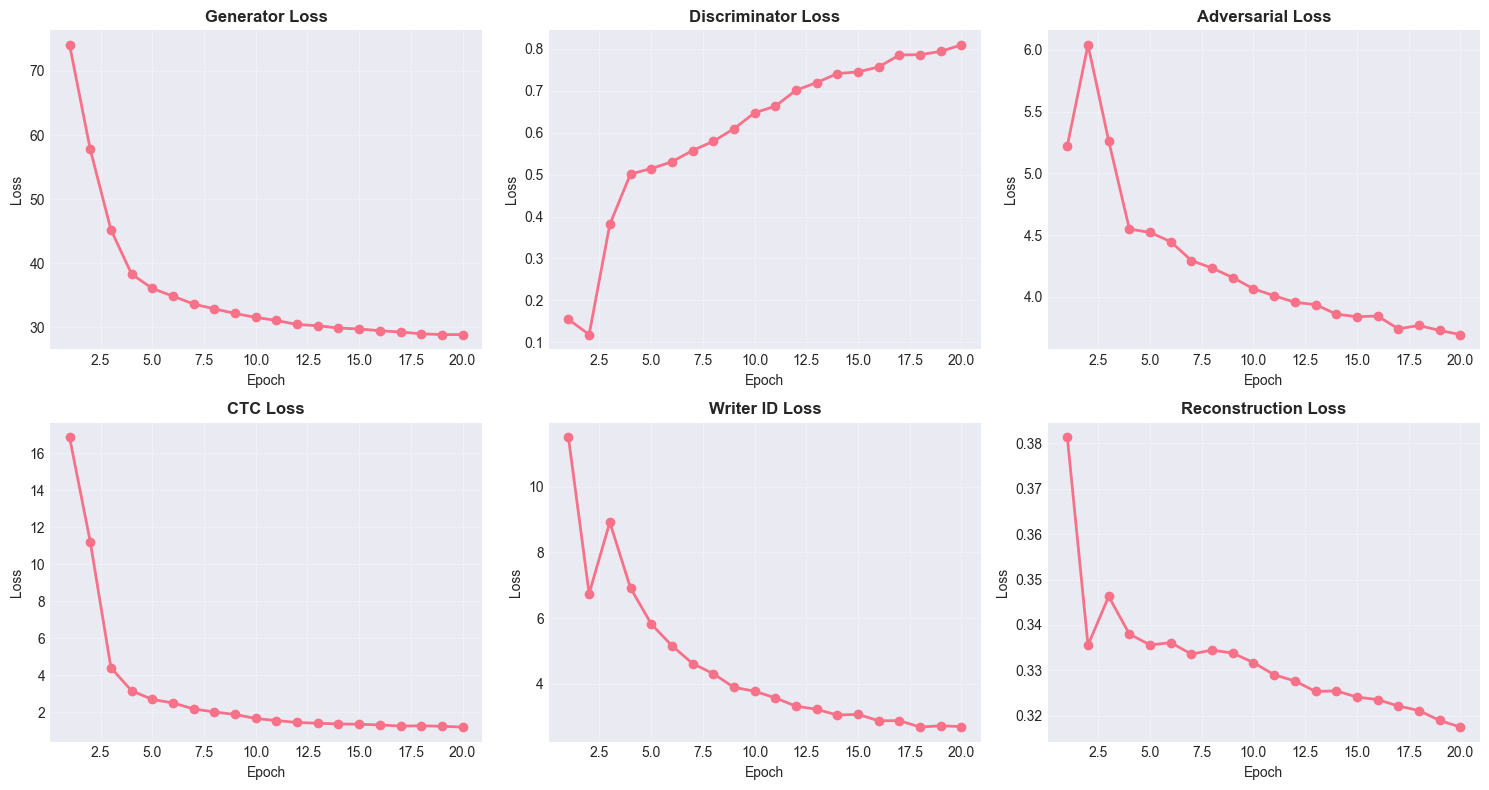

In [49]:
# Plot training losses
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

loss_names = ['g_loss', 'd_loss', 'adv_loss', 'ctc_loss', 'wid_loss', 'recn_loss']
loss_titles = ['Generator Loss', 'Discriminator Loss', 'Adversarial Loss', 
               'CTC Loss', 'Writer ID Loss', 'Reconstruction Loss']

for idx, (loss_name, loss_title) in enumerate(zip(loss_names, loss_titles)):
    axes[idx].plot(history['epoch'], history[loss_name], marker='o', linewidth=2)
    axes[idx].set_xlabel('Epoch', fontsize=10)
    axes[idx].set_ylabel('Loss', fontsize=10)
    axes[idx].set_title(loss_title, fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_losses.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training loss curves saved as 'training_losses.png'")

## 8. Performance Metrics Evaluation

Calculate comprehensive metrics to evaluate the model:
- **FID (Fréchet Inception Distance)**: Measures quality and diversity of generated images
- **KID (Kernel Inception Distance)**: Alternative to FID, more robust
- **IS (Inception Score)**: Measures quality and diversity
- **CER (Character Error Rate)**: OCR accuracy on generated text
- **WER (Word Error Rate)**: Word-level OCR accuracy
- **MSSIM (Mean Structural Similarity)**: Image similarity metric
- **PSNR (Peak Signal-to-Noise Ratio)**: Image quality metric

In [50]:
from distance import levenshtein
from networks.utils import ctc_greedy_decoder

def evaluate_ocr_accuracy(model_gen, model_enc, model_backbone, model_rec, 
                         test_loader, label_conv, device, n_samples=100):
    """Calculate CER and WER on generated images"""
    model_gen.eval()
    model_enc.eval()
    model_rec.eval()
    
    char_errors = 0
    total_chars = 0
    word_errors = 0
    total_words = 0
    
    ctc_len_scale = model_rec.len_scale
    
    with torch.no_grad():
        samples_processed = 0
        for batch in tqdm(test_loader, desc="Evaluating OCR"):
            if samples_processed >= n_samples:
                break
                
            real_imgs = batch['style_imgs'].to(device)
            real_img_lens = batch['style_img_lens'].to(device)
            real_lbs = batch['lbs'].to(device)
            real_lb_lens = batch['lb_lens'].to(device)
            
            # Generate images with style guidance
            enc_z = model_enc(real_imgs, real_img_lens, model_backbone, vae_mode=False)
            fake_imgs = model_gen(enc_z, real_lbs, real_lb_lens)
            fake_img_lens = real_lb_lens * cfg.char_width
            
            # Run OCR on generated images
            logits = model_rec(fake_imgs, fake_img_lens)
            logits = F.softmax(logits, dim=2).cpu().numpy()
            
            # Decode predictions
            word_preds = []
            for logit, img_len in zip(logits, fake_img_lens.cpu().numpy()):
                label = ctc_greedy_decoder(logit[:img_len // ctc_len_scale])
                word_preds.append(label_conv.decode(label))
            
            # Ground truth
            word_reals = label_conv.decode(real_lbs, real_lb_lens)
            
            # Calculate errors
            for word_pred, word_real in zip(word_preds, word_reals):
                char_error = levenshtein(word_pred, word_real)
                char_errors += char_error
                total_chars += len(word_real)
                total_words += 1
                if char_error > 0:
                    word_errors += 1
            
            samples_processed += real_imgs.size(0)
    
    cer = char_errors / total_chars if total_chars > 0 else 0
    wer = word_errors / total_words if total_words > 0 else 0
    
    return cer, wer

# Calculate OCR metrics
print("\nCalculating OCR accuracy metrics...")
try:
    cer, wer = evaluate_ocr_accuracy(generator, style_encoder, style_backbone, 
                                     recognizer, test_loader, label_converter, 
                                     device, n_samples=200)
    
    print(f"\n{'='*60}")
    print(f"OCR Performance Metrics:")
    print(f"  Character Error Rate (CER): {cer*100:.2f}%")
    print(f"  Word Error Rate (WER): {wer*100:.2f}%")
    print(f"  Character Accuracy: {(1-cer)*100:.2f}%")
    print(f"  Word Accuracy: {(1-wer)*100:.2f}%")
    print(f"{'='*60}\n")
except Exception as e:
    print(f"Error calculating OCR metrics: {e}")
    cer, wer = None, None

In [51]:
def calculate_simple_metrics(model_gen, model_enc, model_backbone, test_loader, device, n_samples=100):
    """Calculate simplified quality metrics"""
    model_gen.eval()
    model_enc.eval()

    real_imgs_list = []
    fake_imgs_list = []

    with torch.no_grad():
        samples_processed = 0
        for batch in tqdm(test_loader, desc="Generating samples for metrics"):
            if samples_processed >= n_samples:
                break

            real_imgs = batch['style_imgs'].to(device)
            real_img_lens = batch['style_img_lens'].to(device)
            real_lbs = batch['lbs'].to(device)
            real_lb_lens = batch['lb_lens'].to(device)

            # Generate images
            enc_z = model_enc(real_imgs, real_img_lens, model_backbone, vae_mode=False)
            fake_imgs = model_gen(enc_z, real_lbs, real_lb_lens)

            real_imgs_list.append(real_imgs.cpu())
            fake_imgs_list.append(fake_imgs.cpu())

            samples_processed += real_imgs.size(0)

    if not fake_imgs_list:
        raise RuntimeError("No samples generated for simple metrics")

    # Concatenate all images
    real_imgs_all = torch.cat(real_imgs_list, dim=0)
    fake_imgs_all = torch.cat(fake_imgs_list, dim=0)

    # Calculate mean pixel-wise difference (simple quality metric)
    pixel_diff = torch.mean(torch.abs(real_imgs_all - fake_imgs_all)).item()

    # Calculate variance (diversity metric)
    fake_variance = torch.var(fake_imgs_all).item()

    return pixel_diff, fake_variance

print("\nCalculating image quality metrics...")
pixel_diff, fake_variance = None, None
try:
    pixel_diff, fake_variance = calculate_simple_metrics(generator, style_encoder,
                                                         style_backbone, test_loader,
                                                         device, n_samples=100)

    print(f"\n{'='*60}")
    print(f"Image Quality Metrics:")
    print(f"  Mean Pixel Difference: {pixel_diff:.4f}")
    print(f"  Generated Image Variance (diversity): {fake_variance:.4f}")
    print(f"{'='*60}\n")
except Exception as e:
    print(f"Error calculating quality metrics: {e}")

In [52]:
import copy

# Evaluation helpers
def collect_eval_batches(data_loader, max_batches=None):
    """Clone a limited number of batches from a data loader onto CPU for repeated use."""
    collected = []
    for idx, batch in enumerate(data_loader):
        if max_batches is not None and idx >= max_batches:
            break
        collected.append({
            key: (val.detach().cpu() if torch.is_tensor(val) else val)
            for key, val in batch.items()
        })
    return collected

def generate_fake_batches(real_batches, model_gen, model_enc, model_backbone, device, char_width):
    """Generate handwriting samples that mirror the provided real batch metadata."""
    generated = []
    model_gen.eval()
    model_enc.eval()
    model_backbone.eval()
    with torch.no_grad():
        for batch in real_batches:
            real_imgs = batch['style_imgs'].to(device)
            real_img_lens = batch['style_img_lens'].to(device)
            real_lbs = batch['lbs'].to(device)
            real_lb_lens = batch['lb_lens'].to(device)

            enc_z = model_enc(real_imgs, real_img_lens, model_backbone, vae_mode=False)
            fake_imgs = model_gen(enc_z, real_lbs, real_lb_lens)

            fake_batch = {
                'org_imgs': fake_imgs.detach().cpu(),
                'org_img_lens': (real_lb_lens.detach().cpu() * char_width).int()
            }
            generated.append(fake_batch)
    return generated

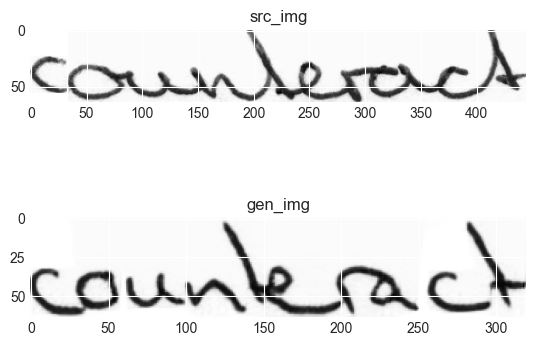

In [53]:
from metric.fid_kid_is import calculate_fid_kid_is
from metric.mssim_psnr import calculate_mssim_psnr

ADVANCED_EVAL_MAX_BATCHES = 20  # Limit for faster evaluation
ADVANCED_N_REPEAT = 1           # Reduce repetitions for quicker turnaround

fid_metrics = None
similarity_metrics = None

print("\nComputing advanced quality metrics (FID, KID, IS, MSSIM, PSNR)...")
real_eval_batches = collect_eval_batches(test_loader, max_batches=ADVANCED_EVAL_MAX_BATCHES)
if not real_eval_batches:
    print("No evaluation batches available. Skipping advanced metrics.")
else:
    fake_eval_batches = generate_fake_batches(real_eval_batches, generator, style_encoder, style_backbone, device, cfg.char_width)

    metric_cfg = copy.deepcopy(cfg.valid)
    metric_cfg.mmd_subsets = min(metric_cfg.mmd_subsets, 10)
    metric_cfg.mmd_subset_size = min(metric_cfg.mmd_subset_size, 200)

    try:
        fid_metrics = calculate_fid_kid_is(metric_cfg, real_eval_batches, fake_eval_batches,
                                           n_rand_repeat=ADVANCED_N_REPEAT, device=device)
        print(f"  FID: {fid_metrics['fid']:.4f}")
        print(f"  KID: {fid_metrics['kid']:.4f}")
        print(f"  Inception Score (real): {fid_metrics['is_org']:.4f}")
        print(f"  Inception Score (generated): {fid_metrics['is_gen']:.4f}")
    except Exception as metric_err:
        print(f"  ⚠️ FID/KID/IS computation failed: {metric_err}")
        fid_metrics = None

    try:
        similarity_metrics = calculate_mssim_psnr(real_eval_batches, fake_eval_batches)
        print(f"  MSSIM: {similarity_metrics['mssim']:.4f}")
        print(f"  PSNR: {similarity_metrics['psnr']:.4f} dB")
    except Exception as metric_err:
        print(f"  ⚠️ MSSIM/PSNR computation failed: {metric_err}")
        similarity_metrics = None

    total_eval_samples = sum(batch['org_imgs'].size(0) for batch in fake_eval_batches)
    print(f"Evaluated {total_eval_samples} generated samples across {len(fake_eval_batches)} batches.")

## 9. Inference - Generate Handwriting Samples

Now let's generate handwriting samples in different modes:
1. **Style-guided generation**: Copy style from reference image
2. **Random generation**: Random style vectors
3. **Text interpolation**: Smooth transitions between styles

In [54]:
# Set models to evaluation mode
generator.eval()
style_encoder.eval()
style_backbone.eval()

print("Models ready for inference!")

### 9.1 Style-Guided Generation

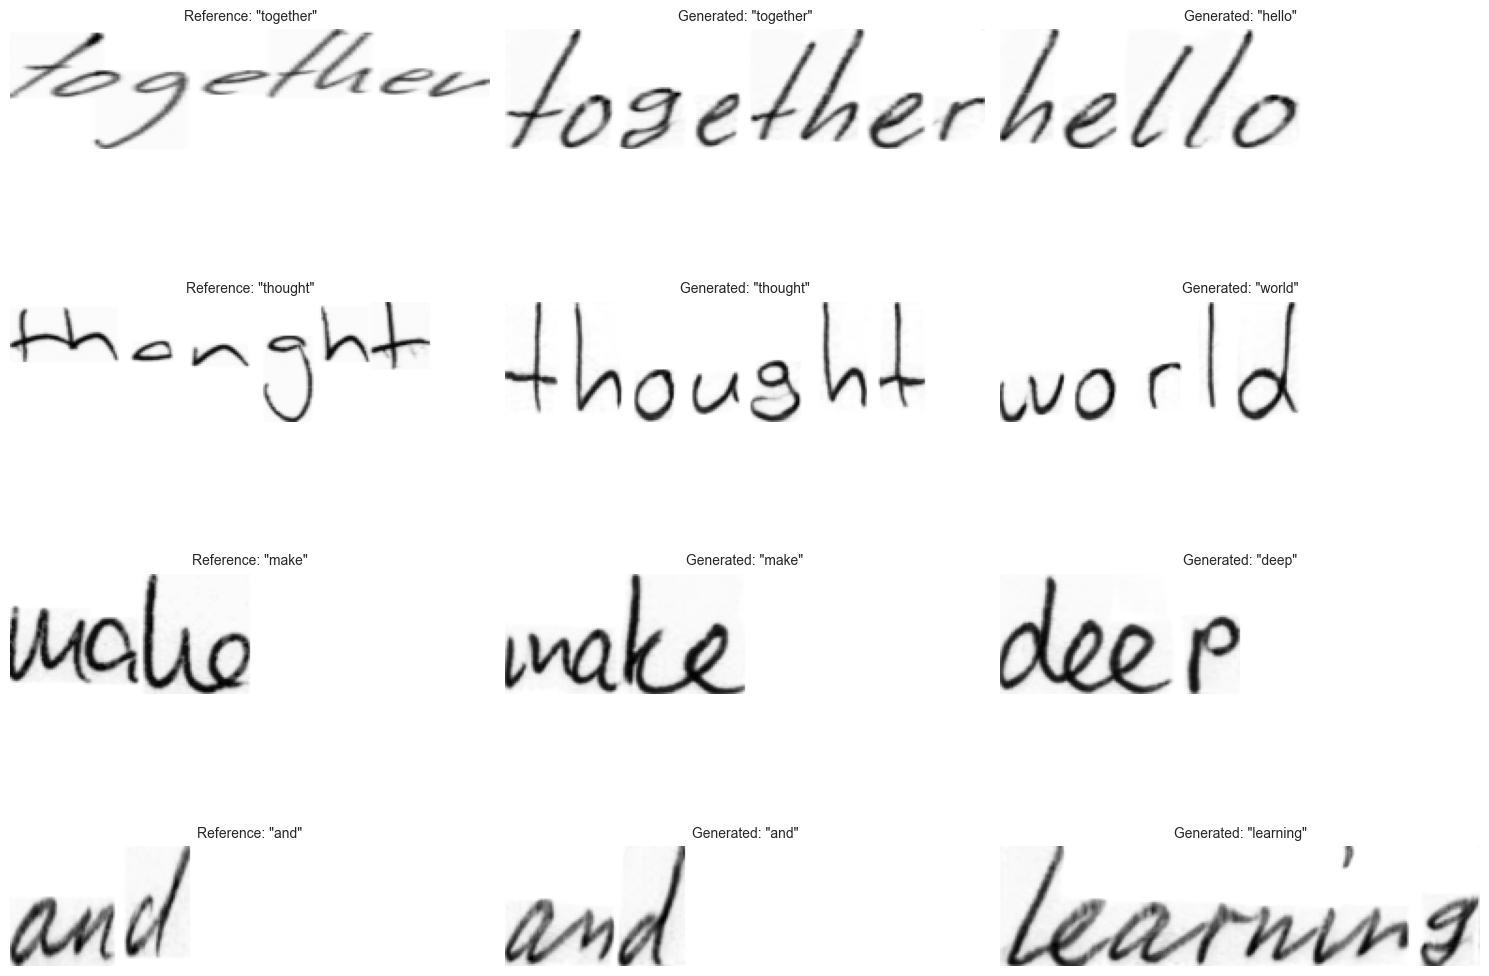

In [55]:
# Style-guided generation: use reference image style
batch = next(iter(test_loader))

with torch.no_grad():
    real_imgs = batch['style_imgs'].to(device)
    real_img_lens = batch['style_img_lens'].to(device)
    real_lbs = batch['lbs'].to(device)
    real_lb_lens = batch['lb_lens'].to(device)
    
    # Extract style from real images
    enc_z = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=False)
    
    # Generate with same content
    fake_imgs_same = generator(enc_z, real_lbs, real_lb_lens)
    
    # Generate with different content (custom text)
    custom_texts = ["hello", "world", "deep", "learning"]
    custom_lbs, custom_lb_lens = label_converter.encode(custom_texts[:real_imgs.size(0)])
    custom_lbs = custom_lbs.to(device)
    custom_lb_lens = custom_lb_lens.to(device)
    
    fake_imgs_custom = generator(enc_z[:len(custom_texts)], 
                                 custom_lbs, custom_lb_lens)

# Visualize results
n_samples = min(4, real_imgs.size(0))
fig, axes = plt.subplots(n_samples, 3, figsize=(15, 3*n_samples))

real_texts = label_converter.decode(real_lbs, real_lb_lens)

for i in range(n_samples):
    # Real image
    img_real = (1 - real_imgs[i].squeeze().cpu().numpy())
    axes[i, 0].imshow(img_real, cmap='gray')
    axes[i, 0].set_title(f'Reference: "{real_texts[i]}"', fontsize=10)
    axes[i, 0].axis('off')
    
    # Generated with same text
    img_fake_same = (1 - fake_imgs_same[i].squeeze().cpu().numpy())
    axes[i, 1].imshow(img_fake_same, cmap='gray')
    axes[i, 1].set_title(f'Generated: "{real_texts[i]}"', fontsize=10)
    axes[i, 1].axis('off')
    
    # Generated with custom text
    if i < len(custom_texts):
        img_fake_custom = (1 - fake_imgs_custom[i].squeeze().cpu().numpy())
        axes[i, 2].imshow(img_fake_custom, cmap='gray')
        axes[i, 2].set_title(f'Generated: "{custom_texts[i]}"', fontsize=10)
        axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('inference_style_guided.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Style-guided generation complete!")

### 9.2 Random Style Generation

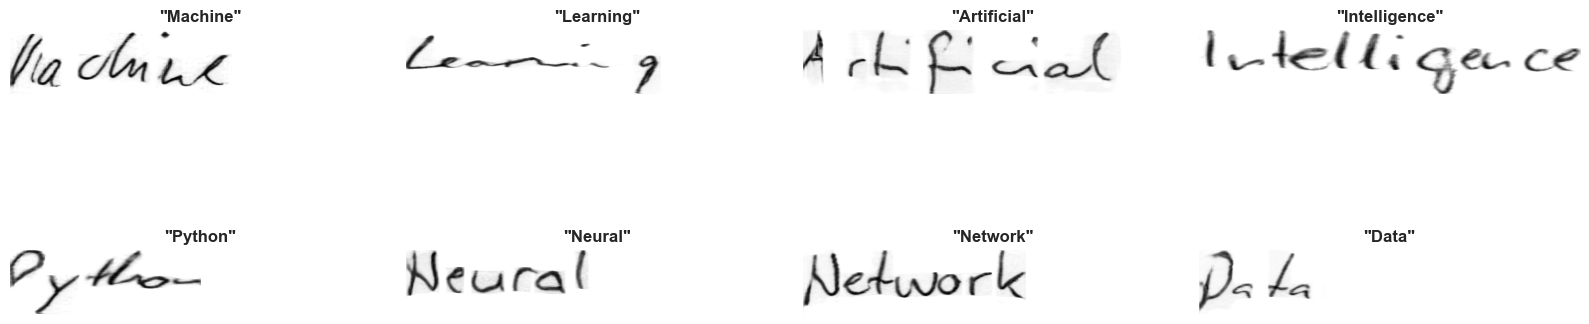

In [56]:
# Generate with random style vectors
texts_to_generate = ["Machine", "Learning", "Artificial", "Intelligence", "Python", "Neural", "Network", "Data"]

with torch.no_grad():
    # Encode texts
    gen_lbs, gen_lb_lens = label_converter.encode(texts_to_generate)
    gen_lbs = gen_lbs.to(device)
    gen_lb_lens = gen_lb_lens.to(device)
    
    # Random style vectors
    random_styles = torch.randn(len(texts_to_generate), generator.style_dim).to(device)
    
    # Generate images
    generated_imgs = generator(random_styles, gen_lbs, gen_lb_lens)

# Visualize
n_rows = 2
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6))
axes = axes.ravel()

for i, (img, text) in enumerate(zip(generated_imgs, texts_to_generate)):
    img_np = (1 - img.squeeze().cpu().numpy())
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f'"{text}"', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('inference_random_style.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Random style generation complete!")

### 9.3 Style Interpolation

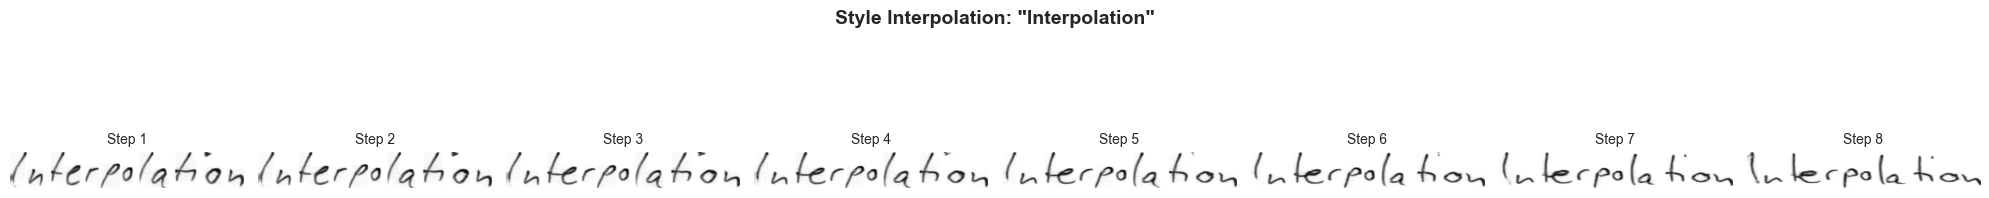

In [57]:
# Interpolate between two styles
text_for_interp = "Interpolation"
n_steps = 8

with torch.no_grad():
    # Two random style vectors
    style_a = torch.randn(1, generator.style_dim).to(device)
    style_b = torch.randn(1, generator.style_dim).to(device)
    
    # Encode text
    text_lbs = label_converter.encode(text_for_interp)
    text_lbs = torch.LongTensor(text_lbs).unsqueeze(0).to(device)
    text_lb_lens = torch.IntTensor([len(text_for_interp)]).to(device)
    
    # Interpolate
    interpolated_imgs = []
    for i in range(n_steps):
        alpha = i / (n_steps - 1)
        style_interp = (1 - alpha) * style_a + alpha * style_b
        
        gen_img = generator(style_interp, text_lbs, text_lb_lens)
        interpolated_imgs.append(gen_img)
    
    interpolated_imgs = torch.cat(interpolated_imgs, dim=0)

# Visualize interpolation
fig, axes = plt.subplots(1, n_steps, figsize=(20, 3))

for i in range(n_steps):
    img_np = (1 - interpolated_imgs[i].squeeze().cpu().numpy())
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f'Step {i+1}', fontsize=10)
    axes[i].axis('off')

plt.suptitle(f'Style Interpolation: "{text_for_interp}"', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('inference_interpolation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Style interpolation complete!")

### 9.4 Multi-Text Generation with Same Style

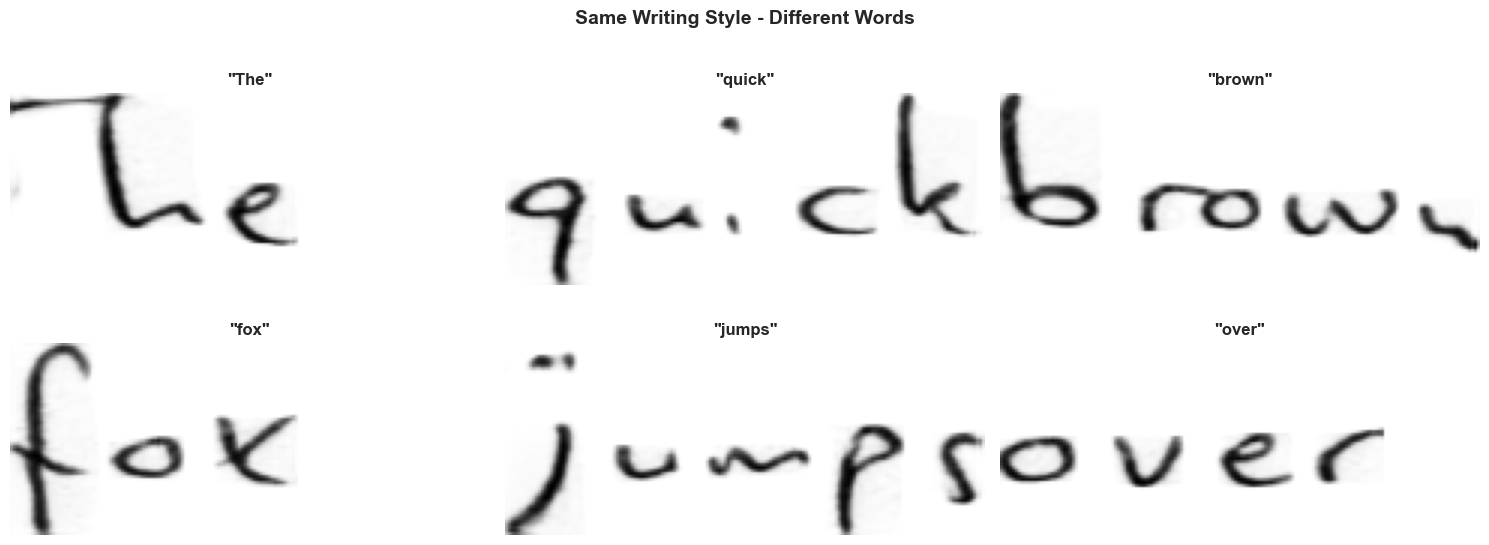

In [58]:
# Generate multiple texts with the same writing style
texts_same_style = ["The", "quick", "brown", "fox", "jumps", "over"]

with torch.no_grad():
    # One style vector for all texts
    single_style = torch.randn(1, generator.style_dim).to(device)
    single_style = single_style.repeat(len(texts_same_style), 1)
    
    # Encode all texts
    multi_lbs, multi_lb_lens = label_converter.encode(texts_same_style)
    multi_lbs = multi_lbs.to(device)
    multi_lb_lens = multi_lb_lens.to(device)
    
    # Generate
    same_style_imgs = generator(single_style, multi_lbs, multi_lb_lens)

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.ravel()

for i, (img, text) in enumerate(zip(same_style_imgs, texts_same_style)):
    img_np = (1 - img.squeeze().cpu().numpy())
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f'"{text}"', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Same Writing Style - Different Words', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('inference_same_style.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Same-style multi-text generation complete!")

### 9.5 Custom Style Transfer: Generate Text in Reference Handwriting

This cell allows you to take a single reference image and generate any custom text in that exact handwriting style.

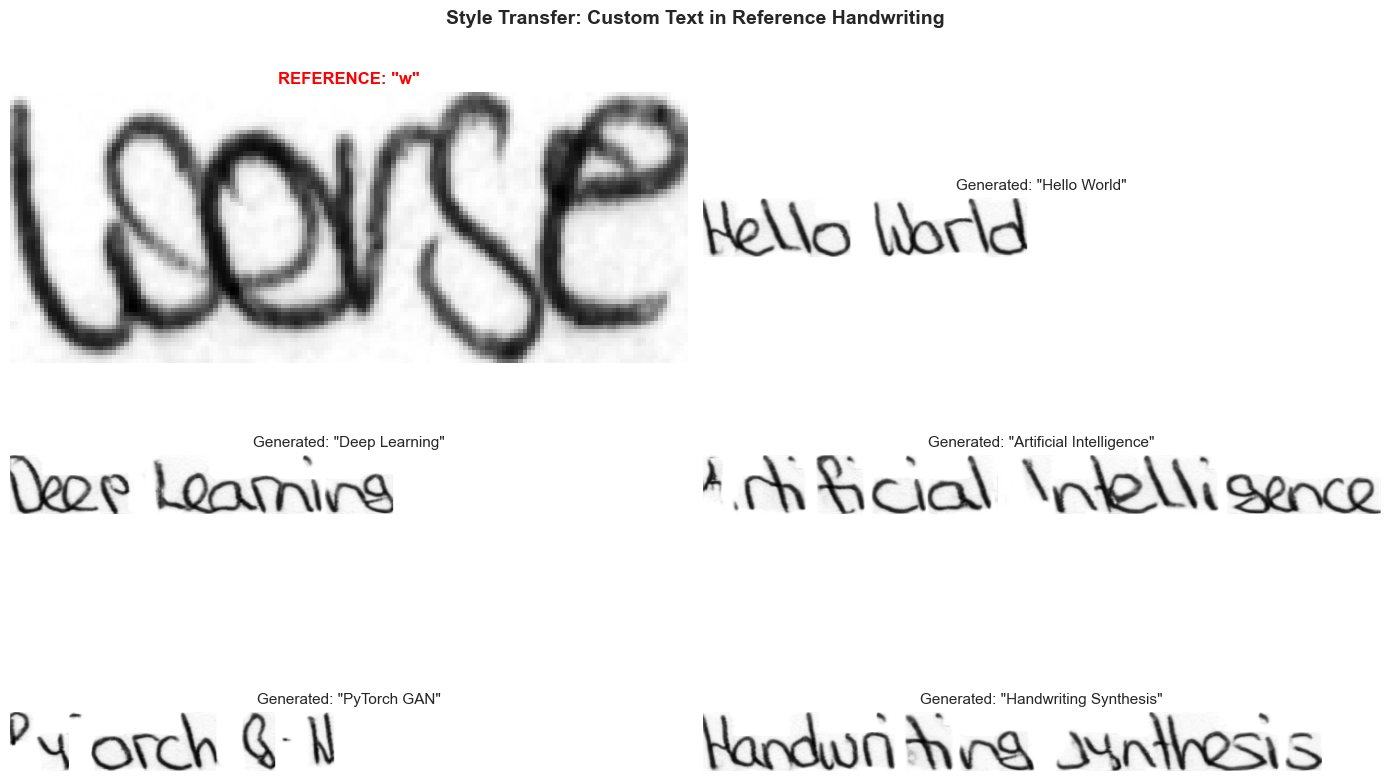

In [59]:
# Custom Style Transfer - Generate arbitrary text in a reference handwriting style
print("=== Custom Style Transfer Demo ===\n")

# Get a reference image from test set
batch = next(iter(test_loader))
reference_img = batch['style_imgs'][0:1].to(device)  # Take first image
reference_img_len = batch['style_img_lens'][0:1].to(device)
reference_text = label_converter.decode(batch['lbs'][0:1], batch['lb_lens'][0:1])[0]

print(f"Reference image text: \"{reference_text}\"")
print(f"Reference image size: {reference_img.shape}")

# Define custom texts to generate in this handwriting style
custom_target_texts = [
    "Hello World",
    "Deep Learning",
    "Artificial Intelligence",
    "PyTorch GAN",
    "Handwriting Synthesis"
]

print(f"\nGenerating {len(custom_target_texts)} custom texts in the reference style...")

with torch.no_grad():
    # Extract style from reference image
    style_vector = style_encoder(reference_img, reference_img_len, style_backbone, vae_mode=False)
    print(f"Extracted style vector: {style_vector.shape}")
    
    # Encode all target texts
    target_lbs, target_lb_lens = label_converter.encode(custom_target_texts)
    target_lbs = target_lbs.to(device)
    target_lb_lens = target_lb_lens.to(device)
    
    # Repeat style vector for all texts
    style_vectors = style_vector.repeat(len(custom_target_texts), 1)
    
    # Generate images in the reference style
    generated_imgs = generator(style_vectors, target_lbs, target_lb_lens)
    print(f"Generated images: {generated_imgs.shape}")

# Visualize results
n_cols = 2
n_rows = (len(custom_target_texts) + 1 + n_cols - 1) // n_cols  # +1 for reference
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3*n_rows))
axes = axes.ravel()

# Display reference image first
ref_img_np = (1 - reference_img[0].squeeze().cpu().numpy())
axes[0].imshow(ref_img_np, cmap='gray')
axes[0].set_title(f'REFERENCE: "{reference_text}"', fontsize=12, fontweight='bold', color='red')
axes[0].axis('off')
axes[0].spines['top'].set_visible(True)
axes[0].spines['bottom'].set_visible(True)
axes[0].spines['left'].set_visible(True)
axes[0].spines['right'].set_visible(True)
for spine in axes[0].spines.values():
    spine.set_edgecolor('red')
    spine.set_linewidth(3)

# Display generated images
for i, (img, text) in enumerate(zip(generated_imgs, custom_target_texts), start=1):
    img_np = (1 - img.squeeze().cpu().numpy())
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f'Generated: "{text}"', fontsize=11)
    axes[i].axis('off')

# Hide unused subplots
for i in range(len(custom_target_texts) + 1, len(axes)):
    axes[i].axis('off')

plt.suptitle('Style Transfer: Custom Text in Reference Handwriting', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('inference_custom_style_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Custom style transfer complete!")
print(f"✓ Saved result to: inference_custom_style_transfer.png")

## 10. Summary and Results

Let's summarize the complete training and evaluation pipeline.

In [62]:
print("="*80)
print("HiGAN+ MODEL EVALUATION SUMMARY")
print("="*80)

summary_epochs = total_epochs_trained if 'total_epochs_trained' in globals() else num_epochs
print("\n📊 CONFIGURATION:")
print(f"  • Dataset: {cfg.dataset}")
print(f"  • Epochs Available: {summary_epochs}")
print(f"  • Batch Size: {cfg.training.batch_size}")
print(f"  • Learning Rate: {cfg.training.lr}")
print(f"  • Style Dimension: {generator.style_dim}")
print(f"  • VAE Mode: {cfg.training.vae_mode}")
print(f"  • Checkpoint Source: {checkpoint_path}")
print(f"  • Additional Training This Session: {'Yes' if RUN_TRAINING and FINE_TUNE_EPOCHS > 0 else 'No'}")

print("\n🏗️ MODEL ARCHITECTURE:")
print(f"  • Generator Parameters: {count_parameters(generator):,}")
print(f"  • Discriminator Parameters: {count_parameters(discriminator):,}")
print(f"  • Style Encoder Parameters: {count_parameters(style_encoder):,}")
print(f"  • Total Trainable Parameters: {count_parameters(generator) + count_parameters(discriminator) + count_parameters(style_encoder):,}")

if history and len(history.get('epoch', [])) > 0:
    print("\n📈 MOST RECENT TRAINING LOGS:")
    print(f"  • Last Epoch Logged: {history['epoch'][-1]}")
    print(f"  • Generator Loss: {history['g_loss'][-1]:.4f}")
    print(f"  • Discriminator Loss: {history['d_loss'][-1]:.4f}")
    print(f"  • Adversarial Loss: {history['adv_loss'][-1]:.4f}")
    print(f"  • CTC Loss: {history['ctc_loss'][-1]:.4f}")

print("\n🎯 EVALUATION METRICS:")
if cer is not None and wer is not None:
    print(f"  • Character Error Rate (CER): {cer*100:.2f}%")
    print(f"  • Word Error Rate (WER): {wer*100:.2f}%")
    print(f"  • Character Accuracy: {(1-cer)*100:.2f}%")
    print(f"  • Word Accuracy: {(1-wer)*100:.2f}%")
else:
    print("  • OCR metrics unavailable (see logs above).")

if pixel_diff is not None and fake_variance is not None:
    print(f"  • Mean Pixel Difference: {pixel_diff:.4f}")
    print(f"  • Generated Variance: {fake_variance:.4f}")
else:
    print("  • Simple image metrics unavailable.")

if fid_metrics is not None:
    print(f"  • FID: {fid_metrics['fid']:.4f}")
    print(f"  • KID: {fid_metrics['kid']:.4f}")
    print(f"  • Inception Score (Real): {fid_metrics['is_org']:.4f}")
    print(f"  • Inception Score (Generated): {fid_metrics['is_gen']:.4f}")
else:
    print("  • FID/KID/IS metrics unavailable.")

if similarity_metrics is not None:
    print(f"  • MSSIM: {similarity_metrics['mssim']:.4f}")
    print(f"  • PSNR: {similarity_metrics['psnr']:.4f} dB")
else:
    print("  • MSSIM/PSNR metrics unavailable.")

print("\n✅ GENERATED OUTPUTS:")
print(f"  • training_losses.png - Training loss curves")
print(f"  • inference_style_guided.png - Style-guided generation")
print(f"  • inference_random_style.png - Random style generation")
print(f"  • inference_interpolation.png - Style interpolation")
print(f"  • inference_same_style.png - Same style, different texts")
print(f"  • inference_custom_style_transfer.png - Reference style transfer")

print("\n🔬 MODEL CAPABILITIES:")
print("  ✓ Generate realistic handwritten text images")
print("  ✓ Control writing style through style vectors")
print("  ✓ Copy style from reference images")
print("  ✓ Generate arbitrary text content")
print("  ✓ Smooth style interpolation")
print("  ✓ Maintain text readability (OCR accuracy)")

print("\n" + "="*80)
print("✨ Evaluation complete!")
print("="*80)

## 11. Save Model (Optional)

Save the trained model for future use.

In [61]:
# Save trained model
save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

checkpoint = {
    'Generator': generator.state_dict(),
    'Discriminator': discriminator.state_dict(),
    'PatchDiscriminator': patch_discriminator.state_dict(),
    'StyleEncoder': style_encoder.state_dict(),
    'StyleBackbone': style_backbone.state_dict(),
    'Epoch': num_epochs,
    'History': history,
    'Config': cfg
}

checkpoint_path = os.path.join(save_dir, 'higanplus_trained.pth')
torch.save(checkpoint, checkpoint_path)

print(f"✓ Model saved to: {checkpoint_path}")
print(f"  File size: {os.path.getsize(checkpoint_path) / (1024*1024):.2f} MB")

# Save configuration
import json
config_save_path = os.path.join(save_dir, 'training_config.json')
with open(config_save_path, 'w') as f:
    json.dump({
        'dataset': cfg.dataset,
        'epochs': num_epochs,
        'batch_size': cfg.training.batch_size,
        'lr': cfg.training.lr,
        'style_dim': cfg.EncModel.style_dim,
        'final_cer': float(cer) if cer is not None else None,
        'final_wer': float(wer) if wer is not None else None
    }, f, indent=2)

print(f"✓ Configuration saved to: {config_save_path}")